# Segmentation Modeling

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df_model = pd.read_csv("employee_attrition_clean.csv")

df_model.shape

(849999, 21)

In [2]:
df_model.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,...,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime,burnout_indicator_score,new_employee
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,...,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351,False,1.043363,False
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,...,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509,False,0.169181,False
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,...,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999,False,0.594795,True
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,...,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184,False,1.307255,False
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,...,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404,False,0.723572,False


In [3]:
features = df_model.select_dtypes(include="number")
features.columns

Index(['tenure_months', 'salary', 'satisfaction_score', 'workload_score',
       'team_sentiment', 'project_completion_rate', 'overtime_hours',
       'training_participation', 'collaboration_score', 'email_sentiment',
       'goal_achievement_rate', 'stress_level', 'role_complexity_score',
       'career_progression_score', 'feedback_sentiment',
       'burnout_indicator_score'],
      dtype='str')

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### Decide optimal clusters based on elbow method and silhouette score

In [5]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method')

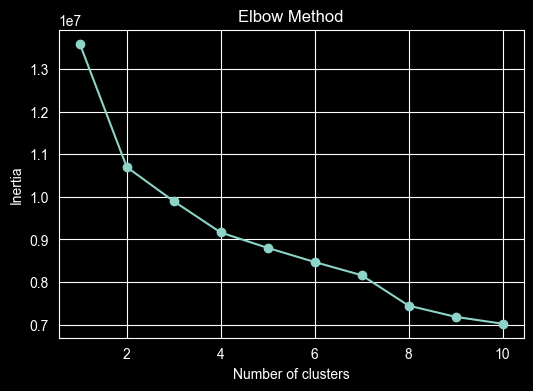

In [6]:
plt.figure(figsize = (6,4))

plt.plot(range(1,11),inertia,marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

In [7]:
sample = features.sample(40000, random_state=42)
sample_scaled = scaler.fit_transform(sample)

silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(sample_scaled)
    scores = silhouette_score(sample_scaled, labels)
    silhouette_scores.append(scores)
    print(f"Score {scores}")

Score 0.19799452281494606
Score 0.14387764040696616
Score 0.14219892619285165
Score 0.1312238054269428
Score 0.11145480133405306
Score 0.10490606375728775
Score 0.10623358653270204
Score 0.10545921149929786
Score 0.10322647399449432


Text(0.5, 1.0, 'Silhouette Score')

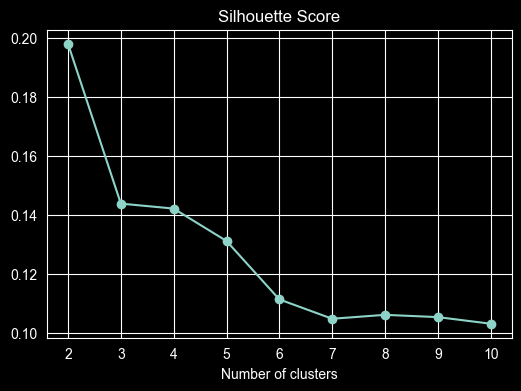

In [8]:
plt.figure(figsize = (6,4))

plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of clusters")
plt.title("Silhouette Score")

### Kmeans chart results
From the elbow graph it looks like 4 clusters is a good amount to keep. In the silhouette score chart we see that 2 clusters has the best results, but a cluster group larger than 2 is optimal for segmenting here, so looking past that we see that from 3-4 there is little change, then once we get past 4 we start to really see a dropoff again, so this chart also supports keeping 4 clusters.

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)



In [10]:
df_model["cluster"] = clusters
df_model["cluster"].value_counts()

cluster
1    258128
2    233402
3    211593
0    146876
Name: count, dtype: int64

In [11]:
cluster_results = df_model.groupby("cluster").mean(numeric_only=True).round(2)
cluster_results

,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime,burnout_indicator_score,new_employee
cluster,,,,,,,,,,,,,,,,,,,
0,72.63,84591.03,0.73,0.34,0.68,0.60,11.68,0.30,0.55,0.73,0.73,0.90,0.28,0.21,0.88,0.68,0.53,0.51,0.15
1,69.24,84159.82,0.85,0.70,0.68,0.69,0.32,0.28,0.61,0.85,0.73,0.47,0.22,0.21,0.86,0.76,0.04,0.32,0.16
2,57.25,86101.58,0.35,0.61,0.66,0.42,2.46,0.20,0.36,0.35,0.51,0.96,0.33,0.21,0.70,0.18,0.15,1.22,0.22
3,84.70,83338.50,0.41,0.64,0.65,0.67,1.37,0.34,0.38,0.41,0.81,0.92,0.32,0.21,0.95,0.27,0.10,1.16,0.10


In [12]:
df_model.groupby("cluster")["left_company"].mean().round(3)

cluster
0    0.284
1    0.216
2    0.331
3    0.320
Name: left_company, dtype: float64

### We can use the results above to start to perform a descriptive analysis of the 4 clusters

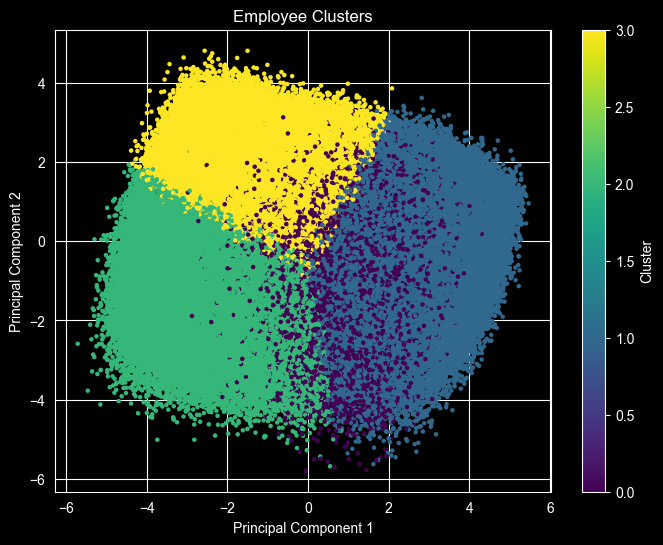

In [13]:
# Use PCA just to create a visual chart of the clusters found

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=5, cmap="viridis")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Employee Clusters")

plt.colorbar(label="Cluster")

## See if our best model improves with cluster label added!

In [14]:
X = df_model.drop("left_company", axis=1)
y = df_model["left_company"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(679999, 21)
(170000, 21)


### We are going to perfrom our supervised modeling again, this time the "cluster" column is added as a predictor variable

In [16]:
cat_features = ["job_level", "department"]
bool_features = ["underpaid_overtime", "new_employee"]
num_features = X_train.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()

print(num_features)
print(cat_features)
print(bool_features)

['tenure_months', 'salary', 'satisfaction_score', 'workload_score', 'team_sentiment', 'project_completion_rate', 'overtime_hours', 'training_participation', 'collaboration_score', 'email_sentiment', 'goal_achievement_rate', 'stress_level', 'role_complexity_score', 'career_progression_score', 'feedback_sentiment', 'burnout_indicator_score', 'cluster']
['job_level', 'department']
['underpaid_overtime', 'new_employee']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
])
dept_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
job_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[["Entry", "Mid", "Senior", "Lead", "Manager"]]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("dep", dept_pipeline, ["department"]),
        ("job", job_pipeline, ["job_level"]),
        ("bool", "passthrough", bool_features)
    ]
)




In [18]:
from xgboost import XGBClassifier

neg = (y_train == False).sum()
pos = (y_train == True).sum()

scale_pos_weight = neg/pos

xgb_model_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    ))
])

xgb_model_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['job_level','department','tenure_months',...,'burnout_indicator_score', 'new_employee','cluster']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [19]:
y_pred_xgb_balanced = xgb_model_balanced.predict(X_test)
y_prob_xgb_balanced = xgb_model_balanced.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_xgb_balanced)
precision = precision_score(y_test, y_pred_xgb_balanced, zero_division=0)
recall = recall_score(y_test, y_pred_xgb_balanced)
f1 = f1_score(y_test, y_pred_xgb_balanced)
roc_auc = roc_auc_score(y_test, y_prob_xgb_balanced)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5308588235294117
Precision: 0.3280016732532667
Recall: 0.6142871868879497
F1: 0.42765490218592567
ROC AUC: 0.5725728154489299


In [21]:
from sklearn.model_selection import RandomizedSearchCV
param_xgb = {
    "model__n_estimators": [100,200, 300],
    "model__max_depth": [3, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2, 3],
    "model__scale_pos_weight": [1, scale_pos_weight]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_balanced,
    param_distributions=param_xgb,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    scoring="f1",
    random_state=42,
    verbose=2,
)

random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

In [22]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'model__subsample': 1.0, 'model__scale_pos_weight': np.float64(2.5047701022054314), 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
0.4372211486457915


In [23]:
tuned_xgb = random_search_xgb.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test)
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_tuned_xgb)
precision = precision_score(y_test, y_pred_tuned_xgb, zero_division=0)
recall = recall_score(y_test, y_pred_tuned_xgb)
f1 = f1_score(y_test, y_pred_tuned_xgb)
roc_auc = roc_auc_score(y_test, y_prob_tuned_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5167823529411765
Precision: 0.3280799656589195
Recall: 0.6617874445933409
F1: 0.43868340314458104
ROC AUC: 0.5805287079096908


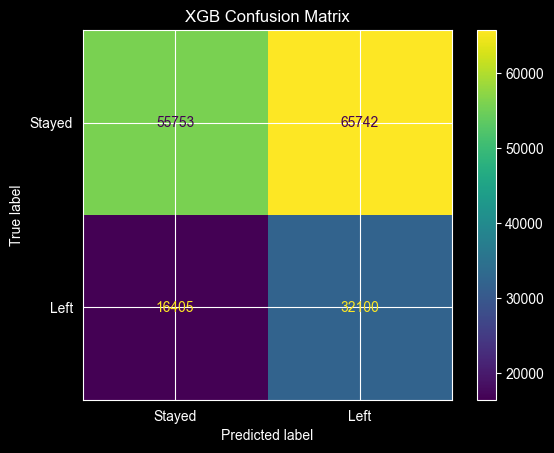

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("XGB Confusion Matrix")
plt.show()

In [25]:
feature = tuned_xgb.named_steps["preprocessor"].get_feature_names_out()
importance = tuned_xgb.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"feature": feature, "importance": importance})
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(10)

,feature,importance
11,num__stress_level,0.387860
15,num__burnout_indicator_score,0.178210
2,num__satisfaction_score,0.088371
16,num__cluster,0.077436
9,num__email_sentiment,0.074669
34,bool__underpaid_overtime,0.063211
3,num__workload_score,0.033799
6,num__overtime_hours,0.016288
8,num__collaboration_score,0.007884
23,dep__department_HR,0.007031


In [26]:
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_pred_threshold = (
        y_prob_tuned_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.285324,0.285324,1.000000,0.443972
1,0.15,0.285324,0.285324,1.000000,0.443972
2,0.20,0.285324,0.285324,1.000000,0.443972
3,0.25,0.285324,0.285324,1.000000,0.443972
4,0.30,0.285324,0.285324,1.000000,0.443972
5,0.35,0.285576,0.285368,0.999773,0.444003
6,0.40,0.369924,0.300583,0.910628,0.451976
7,0.45,0.446618,0.314741,0.798062,0.451442
8,0.50,0.516782,0.328080,0.661787,0.438683
9,0.55,0.633135,0.351857,0.339388,0.345510


### Threshold results
The .40 threshold is still superior, and we do see a very slight improvement from the non segmented model.

### Segmentation seperation modeling

### I am going to attempt to seperate the data into 4 different datasets, and then try and create a model optimized for each cluster.

In [27]:
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
])
dept_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
job_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[["Entry", "Mid", "Senior", "Lead", "Manager"]]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("dep", dept_pipeline, ["department"]),
        ("job", job_pipeline, ["job_level"]),
        ("bool", "passthrough", bool_features)
    ]
)

In [28]:
X_train_0 = X_train[X_train["cluster"] == 0].copy()
y_train_0 = y_train.loc[X_train_0.index]

X_test_0 = X_test[X_test["cluster"] == 0].copy()
y_test_0 = y_test.loc[X_test_0.index]

X_train_0 = X_train_0.drop(columns="cluster")
X_test_0 = X_test_0.drop(columns="cluster")

print("Cluster 0 training rows:", len(X_train_0))
print("Cluster 0 testing rows:", len(X_test_0))
print("Cluster 0 training attrition rate:", y_train_0.mean())



Cluster 0 training rows: 117550
Cluster 0 testing rows: 29326
Cluster 0 training attrition rate: 0.2843726074011059


In [29]:
neg_0 = (y_train_0 == 0).sum()
pos_0 = (y_train_0 == 1).sum()

scale_pos_weight_0 = neg_0 / pos_0

print("Cluster 0 scale_pos_weight:", scale_pos_weight_0)

Cluster 0 scale_pos_weight: 2.516513102788082


In [30]:
segment_model_0 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_0,
        subsample=1.0,
        n_estimators=300,
        min_child_weight=2,
        max_depth=3,
        learning_rate=0.01,
        colsample_bytree=0.8,
    ))
])

segment_model_0.fit(X_train_0, y_train_0)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [31]:
y_pred_xgb_0 = segment_model_0.predict(X_test_0)
y_prob_xgb_0 = segment_model_0.predict_proba(X_test_0)[:, 1]

In [32]:
accuracy = accuracy_score(y_test_0, y_pred_xgb_0)
precision = precision_score(y_test_0, y_pred_xgb_0, zero_division=0)
recall = recall_score(y_test_0, y_pred_xgb_0)
f1 = f1_score(y_test_0, y_pred_xgb_0)
roc_auc = roc_auc_score(y_test_0, y_prob_xgb_0)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.4800177317056537
Precision: 0.3024997185001689
Recall: 0.6526175148791449
F1: 0.4133871898442008
ROC AUC: 0.5443867561831883


In [33]:
from sklearn.model_selection import RandomizedSearchCV
param_xgb = {
    "model__n_estimators": [100,200, 300],
    "model__max_depth": [3, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2, 3],
    "model__scale_pos_weight": [1, scale_pos_weight_0]
}

random_search_xgb = RandomizedSearchCV(
    estimator=segment_model_0,
    param_distributions=param_xgb,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    scoring="f1",
    random_state=42,
    verbose=2,
)

random_search_xgb.fit(X_train_0, y_train_0)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

In [34]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'model__subsample': 1.0, 'model__scale_pos_weight': np.float64(2.516513102788082), 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
0.41192412932805256


In [35]:
tuned_xgb = random_search_xgb.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test_0)
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test_0)[:, 1]

accuracy = accuracy_score(y_test_0, y_pred_tuned_xgb)
precision = precision_score(y_test_0, y_pred_tuned_xgb, zero_division=0)
recall = recall_score(y_test_0, y_pred_tuned_xgb)
f1 = f1_score(y_test_0, y_pred_tuned_xgb)
roc_auc = roc_auc_score(y_test_0, y_prob_tuned_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.4800177317056537
Precision: 0.3024997185001689
Recall: 0.6526175148791449
F1: 0.4133871898442008
ROC AUC: 0.5443867561831883


Cluster 1

In [36]:
X_train_1 = X_train[X_train["cluster"] == 1].copy()
y_train_1 = y_train.loc[X_train_1.index]

X_test_1 = X_test[X_test["cluster"] == 1].copy()
y_test_1 = y_test.loc[X_test_1.index]

X_train_1 = X_train_1.drop(columns="cluster")
X_test_1 = X_test_1.drop(columns="cluster")

print("Cluster 1 training rows:", len(X_train_1))
print("Cluster 1 testing rows:", len(X_test_1))
print("Cluster 1 training attrition rate:", y_train_1.mean())

Cluster 1 training rows: 206628
Cluster 1 testing rows: 51500
Cluster 1 training attrition rate: 0.2165969762084519


In [37]:
neg_1 = (y_train_1 == 0).sum()
pos_1 = (y_train_1 == 1).sum()

scale_pos_weight_1 = neg_1 / pos_1

print("Cluster 1 scale_pos_weight:", scale_pos_weight_1)

Cluster 1 scale_pos_weight: 3.6168696235057536


In [38]:
segment_model_1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_1,
        subsample=1.0,
        n_estimators=300,
        min_child_weight=2,
        max_depth=3,
        learning_rate=0.01,
        colsample_bytree=0.8,
    ))
])

segment_model_1.fit(X_train_1, y_train_1)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [39]:
y_pred_xgb_1 = segment_model_1.predict(X_test_1)
y_prob_xgb_1 = segment_model_1.predict_proba(X_test_1)[:, 1]

In [40]:
accuracy = accuracy_score(y_test_1, y_pred_xgb_1)
precision = precision_score(y_test_1, y_pred_xgb_1, zero_division=0)
recall = recall_score(y_test_1, y_pred_xgb_1)
f1 = f1_score(y_test_1, y_pred_xgb_1)
roc_auc = roc_auc_score(y_test_1, y_prob_xgb_1)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5478640776699029
Precision: 0.24308108336502302
Recall: 0.5171700827040633
F1: 0.33071771435141273
ROC AUC: 0.548449062362872


In [41]:
param_xgb = {
    "model__n_estimators": [100,200, 300],
    "model__max_depth": [3, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2, 3],
    "model__scale_pos_weight": [1, scale_pos_weight_1]
}

random_search_xgb = RandomizedSearchCV(
    estimator=segment_model_1,
    param_distributions=param_xgb,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    scoring="f1",
    random_state=42,
    verbose=2,
)

random_search_xgb.fit(X_train_1, y_train_1)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

In [42]:
tuned_xgb = random_search_xgb.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test_1)
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test_1)[:, 1]

accuracy = accuracy_score(y_test_1, y_pred_tuned_xgb)
precision = precision_score(y_test_1, y_pred_tuned_xgb, zero_division=0)
recall = recall_score(y_test_1, y_pred_tuned_xgb)
f1 = f1_score(y_test_1, y_pred_tuned_xgb)
roc_auc = roc_auc_score(y_test_1, y_prob_tuned_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5478640776699029
Precision: 0.24308108336502302
Recall: 0.5171700827040633
F1: 0.33071771435141273
ROC AUC: 0.548449062362872


Cluster 2

In [43]:
X_train_2 = X_train[X_train["cluster"] == 2].copy()
y_train_2 = y_train.loc[X_train_2.index]

X_test_2 = X_test[X_test["cluster"] == 2].copy()
y_test_2 = y_test.loc[X_test_2.index]

X_train_2 = X_train_2.drop(columns="cluster")
X_test_2 = X_test_2.drop(columns="cluster")

print("Cluster 2 training rows:", len(X_train_2))
print("Cluster 2 testing rows:", len(X_test_2))
print("Cluster 2 training attrition rate:", y_train_2.mean())

Cluster 2 training rows: 186411
Cluster 2 testing rows: 46991
Cluster 2 training attrition rate: 0.33056525634216866


In [44]:
neg_2 = (y_train_2 == 0).sum()
pos_2 = (y_train_2 == 1).sum()

scale_pos_weight_2 = neg_2 / pos_2

print("Cluster 2 scale_pos_weight:", scale_pos_weight_2)


Cluster 2 scale_pos_weight: 2.0251213060482627


In [45]:
segment_model_2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_2,
        subsample=1.0,
        n_estimators=300,
        min_child_weight=2,
        max_depth=3,
        learning_rate=0.01,
        colsample_bytree=0.8,
    ))
])

segment_model_2.fit(X_train_2, y_train_2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [46]:
y_pred_xgb_2 = segment_model_2.predict(X_test_2)
y_prob_xgb_2 = segment_model_2.predict_proba(X_test_2)[:, 1]

In [47]:
accuracy = accuracy_score(y_test_2, y_pred_xgb_2)
precision = precision_score(y_test_2, y_pred_xgb_2, zero_division=0)
recall = recall_score(y_test_2, y_pred_xgb_2)
f1 = f1_score(y_test_2, y_pred_xgb_2)
roc_auc = roc_auc_score(y_test_2, y_prob_xgb_2)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.4883701134259752
Precision: 0.3492534114453097
Recall: 0.6266504294321241
F1: 0.44852738783374624
ROC AUC: 0.532644031497623


In [48]:
param_xgb = {
    "model__n_estimators": [100,200, 300],
    "model__max_depth": [3, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2, 3],
    "model__scale_pos_weight": [1, scale_pos_weight_2]
}

random_search_xgb = RandomizedSearchCV(
    estimator=segment_model_2,
    param_distributions=param_xgb,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    scoring="f1",
    random_state=42,
    verbose=2,
)

random_search_xgb.fit(X_train_2, y_train_2)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

In [49]:
tuned_xgb = random_search_xgb.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test_2)
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test_2)[:, 1]

accuracy = accuracy_score(y_test_2, y_pred_tuned_xgb)
precision = precision_score(y_test_2, y_pred_tuned_xgb, zero_division=0)
recall = recall_score(y_test_2, y_pred_tuned_xgb)
f1 = f1_score(y_test_2, y_pred_tuned_xgb)
roc_auc = roc_auc_score(y_test_2, y_prob_tuned_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.4883701134259752
Precision: 0.3492534114453097
Recall: 0.6266504294321241
F1: 0.44852738783374624
ROC AUC: 0.532644031497623


## Clustering Segments Modeling Results

The models filtered to individual clusters do not seem to bring about any better results than using the typical full model used before. These results point to the conclusion that using different models on different segments is not a path worth pursing more and we should stick to global models.